# 13 · GNN

Template para `RentalPriceGNN`, con foco en construcción del grafo, evaluación comparable y análisis de qué aprende la red.

## Hipótesis del modelo

- El precio surge de atributos del inmueble y de la estructura relacional entre observaciones cercanas.
- La definición del grafo es parte del modelo y debe documentarse con tanto cuidado como los hiperparámetros.
- La interpretación se apoya más en ablations, embeddings y atención que en importancias clásicas.

In [61]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [62]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import geopandas as gpd
import seaborn as sns
from sklearn.neighbors import BallTree

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from ml_core.models.gat_gcn_model import GraphAttentionGCN
from ml_core.preprocessing.knhs import KNHS
from ml_core.evaluation.modelEvaluator import regression_metrics
from ml_core.visualization.mapper import (
    plot_residuals_map,
    CombinedZLisaMapVisualizer,
)
from ml_core import load_model_config, save_model_config

OUTPUT_DIR = PROJECT_ROOT / "notebooks" / "output" / "13_gnn"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
sns.set_theme(style="whitegrid")


## Datos base

In [63]:
DATA_PATH = PROJECT_ROOT / "data" / "splits"

train_raw = pd.read_csv(DATA_PATH / "arg_venta_data_train.csv")
gdf_train = gpd.GeoDataFrame(
    train_raw,
    geometry=gpd.points_from_xy(
        train_raw["longitud"],
        train_raw["latitud"]
    ),
    crs="EPSG:4326"
)

test_raw = pd.read_csv(DATA_PATH / "arg_venta_data_test.csv")
gdf_test = gpd.GeoDataFrame(
    test_raw,
    geometry=gpd.points_from_xy(
        test_raw["longitud"],
        test_raw["latitud"]
    ),
    crs="EPSG:4326"
)

val_raw = pd.read_csv(DATA_PATH / "arg_venta_data_val.csv")
gdf_val = gpd.GeoDataFrame(
    val_raw,
    geometry=gpd.points_from_xy(
        val_raw["longitud"],
        val_raw["latitud"]
    ),
    crs="EPSG:4326"
)

target_col = "log_precio"   
coord_cols = ["longitud", "latitud"]
feature_cols = [
    'area_m2_total',
    'area_m2_descubierta',
    'ambientes',
    'antiguedad',
    'expensas',
    'banos',
    'cocheras',
    'estado_num',
    'disposicion_Frente',
    'disposicion_Contrafrente',
    'disposicion_Lateral',
    'dist_subte',
    'dist_universidad',
    'dist_hospital',
    'dist_est_educativo',
    'dist_espacio_verde',
    'dist_areas_programaticas',
    'dist_avenida_rivadavia',
    "n_robos_1000m",
    "n_universidades_1000m",
    "pozo",
    "velocidad_ventas_1000m_90d"
]




/tmp/ipykernel_474072/695265548.py:13: DtypeWarning: Columns (0: orientacion, 1: fecha_orde, 2: fecha_bole) have mixed types. Specify dtype option on import or set low_memory=False.
  test_raw = pd.read_csv(DATA_PATH / "arg_venta_data_test.csv")
/tmp/ipykernel_474072/695265548.py:23: DtypeWarning: Columns (0: tipo_unidad, 1: orientacion, 2: fecha_orde, 3: fecha_bole) have mixed types. Specify dtype option on import or set low_memory=False.
  val_raw = pd.read_csv(DATA_PATH / "arg_venta_data_val.csv")


In [64]:
X_train = gdf_train[feature_cols]
y_train = gdf_train[target_col]
coords_train = gdf_train[coord_cols].to_numpy()

X_test = gdf_test[feature_cols]
y_test = gdf_test[target_col]
coords_test = gdf_test[coord_cols].to_numpy()

X_val = gdf_val[feature_cols]
y_val = gdf_val[target_col]
coords_val = gdf_val[coord_cols].to_numpy()


In [65]:
# Hyperparámetros de grafo
k_neighbors = 15  # vecinos por nodo para construir aristas
radius_km = 3.0

def build_graph_frame(X_df, coords_deg_longlat):
    """Convierte coords [longitud, latitud] en grados a columnas lat/lon esperadas por KNHS."""
    coords_arr = np.asarray(coords_deg_longlat, dtype=float)
    if coords_arr.ndim != 2 or coords_arr.shape[1] != 2:
        raise ValueError(
            "coords debe tener shape (n, 2) con columnas [longitud, latitud]. "
            f"Recibido: {coords_arr.shape}."
        )

    graph = X_df.copy().reset_index(drop=True)
    graph["lat_deg"] = coords_arr[:, 1]
    graph["lon_deg"] = coords_arr[:, 0]
    return graph


graph_train = build_graph_frame(X_train, coords_train)
graph_val = build_graph_frame(X_val, coords_val)
graph_test = build_graph_frame(X_test, coords_test)

# Este builder se usa como template del modelo. 
builder = KNHS(
    lat_col="lat_deg",
    lon_col="lon_deg",
    feature_cols=feature_cols,
    weight_cols=None,
    distance="euclidean",
    radius_km=radius_km,
    k=k_neighbors,
    add_reverse=True,
)

edge_index_train, edge_attr_train = builder.build(graph_train)

print("[split-local] Aristas train:", edge_index_train.shape[1])

X_val_cross = pd.concat([X_train.reset_index(drop=True), X_val.reset_index(drop=True)], ignore_index=True)
y_val_cross = pd.concat([y_train.reset_index(drop=True), y_val.reset_index(drop=True)], ignore_index=True)
X_test_cross = pd.concat([X_train.reset_index(drop=True), X_test.reset_index(drop=True)], ignore_index=True)
y_test_cross = pd.concat([y_train.reset_index(drop=True), y_test.reset_index(drop=True)], ignore_index=True)


[split-local] Aristas train: 1152750


## Fine-tuning

Acá barrés hiperparámetros del GNN reutilizando el grafo definido arriba.


## Fine-tuning


In [77]:
config_path = PROJECT_ROOT / "notebooks" / "cache" / "gnn_best_config.json"
saved_config = load_model_config(config_path)
param_grid = {
    "hidden": [96, 128],
    "num_layers": [2, 3],
    "num_heads": [2, 4],
    "dropout": [0.0, 0.1, 0.2],
    "lr": [1e-3, 2e-3],
    "weight_decay": [0.0, 1e-5, 1e-4],
    "loss_name": ["huber"],
    "huber_delta": [0.5, 1.0],
    "grad_clip_norm": [None, 5.0],
}

if saved_config is None:
    tuning_model = GraphAttentionGCN(
        feature_names=feature_cols,
        edge_dim=2,
        num_layers=2,
        weight_decay=1e-4,
        patience=50,
        loss_name="huber",
        huber_delta=0.5,
        grad_clip_norm=5.0,
        knhs_builder=builder,
    )
    tuning_model.tune_hyperparameters(
        X_train,
        y_train,
        coords_train,
        X_val=X_val,
        y_val=y_val,
        coords_val=coords_val,
        param_grid=param_grid,
        search_type="random",
        n_iter=7,
        optimize_metric="mape",
        epochs=600,
        refit_epochs=6000,
        random_state=42,
    )
    save_model_config(
        tuning_model,
        config_path,
        extra={
            "target": target_col,
            "features": feature_cols,
            "graph_params": {
                "k_neighbors": k_neighbors,
                "radius_km": radius_km,
                "graph_distance": "euclidean",
            },
        },
    )
    saved_config = load_model_config(config_path)
best_config = saved_config.get("best_params_", {})
if not best_config:
    raise ValueError(f"No se encontro best_params_ en {config_path}")
best_config


{'hidden': 96,
 'num_layers': 3,
 'num_heads': 2,
 'dropout': 0.45,
 'lr': 0.0005,
 'weight_decay': 0.001,
 'loss_name': 'huber',
 'huber_delta': 0.3,
 'grad_clip_norm': 1.0}

## Entrenamiento


In [67]:
print("Mejor config:", best_config)
print("Cache:", config_path)


Mejor config: {'hidden': 96, 'num_layers': 3, 'num_heads': 2, 'dropout': 0.45, 'lr': 0.0005, 'weight_decay': 0.001, 'loss_name': 'huber', 'huber_delta': 0.3, 'grad_clip_norm': 1.0}
Cache: /home/saneliges/Escritorio/PredictorPrecioMetroCuadradoAlquileres/notebooks/cache/gnn_best_config.json


In [78]:
edge_dim = 2  # distancia km + distancia de features (localmente pesada)
model = GraphAttentionGCN(
    feature_names=feature_cols,
    edge_dim=edge_dim,
    knhs_builder=builder,
    hidden=int(best_config["hidden"]),
    num_layers=int(best_config["num_layers"]),
    num_heads=int(best_config["num_heads"]),
    dropout=float(best_config["dropout"]),
    lr=float(best_config["lr"]),
    weight_decay=float(best_config["weight_decay"]),
    patience=150,
    loss_name=str(best_config["loss_name"]),
    huber_delta=float(best_config["huber_delta"]),
    grad_clip_norm=float(best_config["grad_clip_norm"]),
)
_ = model.fit(
    X_train,
    y_train,
    coords_train,
    epochs=6000,
)
if model.knhs_builder_ is None or not model.knhs_builder_.edge_scaler_fitted_:
    raise RuntimeError("El edge_scaler del KNHS no quedó fitted después de fit().")
print("Edge scaler fitted:", model.knhs_builder_.edge_scaler_fitted_)
model


Early stopping en epoch 923, best loss=0.141240
Edge scaler fitted: True


GraphAttentionGCN(
  (layers): ModuleList(
    (0): GraphAttentionLayer(
      (W_q): Linear(in_features=21, out_features=96, bias=False)
      (W_k): Linear(in_features=21, out_features=96, bias=False)
      (W_v): Linear(in_features=21, out_features=96, bias=False)
      (W_u): Linear(in_features=2, out_features=96, bias=False)
      (edge_bias): Linear(in_features=2, out_features=2, bias=False)
      (skip_proj): Linear(in_features=21, out_features=96, bias=True)
      (gate): Linear(in_features=192, out_features=96, bias=True)
      (activation): ReLU()
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (1-2): 2 x GraphAttentionLayer(
      (W_q): Linear(in_features=96, out_features=96, bias=False)
      (W_k): Linear(in_features=96, out_features=96, bias=False)
      (W_v): Linear(in_features=96, out_features=96, bias=False)
      (W_u): Linear(in_features=2, out_features=96, bias=False)
      (edge_bias): Linear(in_features=2, out_features=2, bias=False)
      (skip_proj): 

## Evaluación global


In [85]:
y_pred_log = model.predict(
    X_val,
    coords_val,
)

y_pred = np.exp(np.asarray(y_pred_log).reshape(-1))
y_true = np.exp(np.asarray(y_val).reshape(-1))

metrics = regression_metrics(y_true, y_pred)
metrics


AttributeError: 'GraphAttentionLayer' object has no attribute 'linear_aggr'

## OOF Outliers

Refactor compartido con `12_rf_kriging`: la deteccion corre sobre folds y solo el armado del modelo/grafo queda especifico del notebook.


In [82]:
from ml_core.outlierAnalysis.oof import (
    detect_outliers_oof,
    load_active_processed_geodata,
)


def build_gnn_model():
    return GraphAttentionGCN(
        feature_names=feature_cols,
        edge_dim=2,
        hidden=int(best_config["hidden"]),
        num_layers=int(best_config["num_layers"]),
        num_heads=int(best_config["num_heads"]),
        dropout=float(best_config["dropout"]),
        lr=float(best_config["lr"]),
        weight_decay=float(best_config["weight_decay"]),
        patience=50,
        loss_name=str(best_config["loss_name"]),
        huber_delta=float(best_config["huber_delta"]),
        grad_clip_norm=float(best_config["grad_clip_norm"]),
        k_neighbors=k_neighbors,
        radius_km=radius_km,
        graph_distance="euclidean",
        knhs_builder=builder,
    )


def gnn_fit_kwargs(context):
    return {}


def gnn_predict_kwargs(context):
    # GraphAttentionGCN construye internamente el grafo cross-split train->target
    # cuando recibe coords en predict(), asi que no necesitamos pasar aristas aca.
    return {}


DATA_PATH = PROJECT_ROOT / "data" / "processed"
barrios_path = PROJECT_ROOT / "GeoData" / "barrios.geojson"

gdf_all = load_active_processed_geodata(
    data_path=DATA_PATH / "arg_venta_data_processed.csv",
    feature_cols=feature_cols,
    target_col=target_col,
    coord_cols=coord_cols,
    extra_cols=["idx", "url", "precio"],
)

X_all = gdf_all[feature_cols]
y_all = gdf_all[target_col]
coords_all = gdf_all[coord_cols].to_numpy()

results_by_method, residuals_oof = detect_outliers_oof(
    model_factory=build_gnn_model,
    X=X_all,
    y=y_all,
    gdf=gdf_all,
    coords=coords_all,
    output_dir=OUTPUT_DIR / "outliers_oof",
    methods=["ztest", "combined_z_lisa"],
    params_for_methods={
        "combined_z_lisa": {
            "alpha": 0.05,
            "permutations": 999,
            "z_threshold": 3.0,
        },
    },
    k_neighbors=15,
    n_splits=5,
    fit_kwargs_resolver=gnn_fit_kwargs,
    predict_kwargs_resolver=gnn_predict_kwargs,
)

results_by_method["combined_z_lisa"].head()



Fold 1/5

Fold 2/5

Fold 3/5

Fold 4/5

Fold 5/5


,idx,url,fold,method,precio,latitud,longitud,valido_hasta,pozo,estado_num,...,n_robos_1000m_scaled,n_universidades_1000m_scaled,geometry,z_score,p_value_z,p_value_lisa,quadrant,combined_score,residuo,is_outlier
0,63916,https://www.argenprop.com/departamento-en-vent...,1,combined_z_lisa,270000.0,-34.586743,-58.453299,NaN,0.0,5,...,-0.472322,-0.629505,POINT (-58.4533 -34.58674),0.124817,1.000000,0.329,HH,0.000000,0.007994,False
1,49855,https://www.argenprop.com/departamento-en-vent...,1,combined_z_lisa,270000.0,-34.638772,-58.500823,NaN,0.0,5,...,-0.709864,-0.629505,POINT (-58.50082 -34.63877),3.011519,1.000000,0.004,HH,0.000000,0.629559,False
2,51225,https://www.argenprop.com/departamento-en-vent...,1,combined_z_lisa,125000.0,-34.602120,-58.448570,NaN,0.0,5,...,-0.116010,-0.629505,POINT (-58.44857 -34.60212),0.851115,1.000000,0.459,HH,0.000000,0.256067,False
3,61580,https://www.argenprop.com/departamento-en-vent...,1,combined_z_lisa,156000.0,-34.608200,-58.393340,NaN,0.0,4,...,1.317724,3.647260,POINT (-58.39334 -34.6082),-0.690399,0.244972,0.865,LH,0.957528,-0.084221,False
4,59117,https://www.argenprop.com/departamento-en-vent...,1,combined_z_lisa,600000.0,-34.554190,-58.490430,NaN,0.0,5,...,-1.108595,-0.465014,POINT (-58.49043 -34.55419),6.087903,1.000000,0.772,HL,-0.228000,1.807675,False


## Residuos espaciales


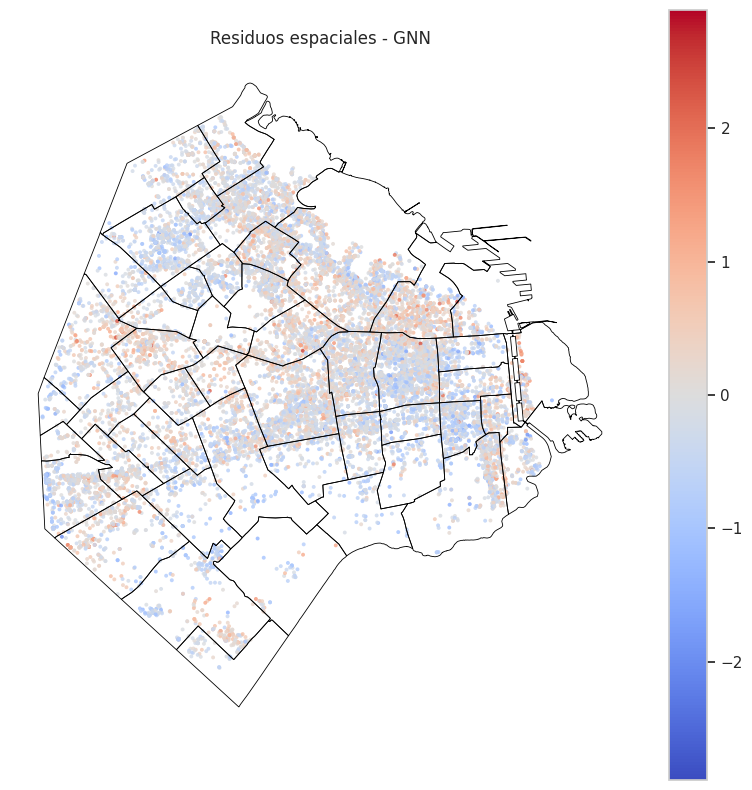

In [83]:
gdf_res = gdf_all.copy()
gdf_res["residual"] = residuals_oof

fig, ax = plot_residuals_map(
    gdf=gdf_res,
    residual_col="residual",
    boundary_path=barrios_path,
    title="Residuos espaciales - GNN",
)


## In sample metrics

In [84]:
y_pred_train_log = model.predict(X_train)

y_pred_train = np.exp(np.asarray(y_pred_train_log).reshape(-1))
y_true_train = np.exp(np.asarray(y_train).reshape(-1))

train_metrics = regression_metrics(y_true_train, y_pred_train)
train_metrics


AttributeError: 'GraphAttentionLayer' object has no attribute 'linear_aggr'

## Outliers Combined Z + LISA


In [76]:
from IPython.display import IFrame, display

combined_z_lisa_visualizer = CombinedZLisaMapVisualizer(
    gdf_all=gdf_all,
    results_df=results_by_method["combined_z_lisa"],
    barrios_path=barrios_path,
)
combined_z_lisa_map = combined_z_lisa_visualizer.build_map()
combined_z_lisa_map_path = OUTPUT_DIR / "outliers_oof" / "combined_z_lisa_interactive_map.html"
combined_z_lisa_visualizer.save_map(combined_z_lisa_map_path)
display(IFrame(src=str(combined_z_lisa_map_path.relative_to(PROJECT_ROOT)), width="100%", height=700))


KeyError: 'ambientes'